In [ ]:
%pip install scikit-learn faiss-cpu

# Data loading

In [ ]:
#@markdown Fetch SIFT10k dataset
"""SIFT datasets are available at http://corpus-texmex.irisa.fr

The following is just a Bash script for downloading and unizipping

N.B. The folder contains a base file for the data matrix and a bunch
of other stuff we don't care about"""

!curl ftp://ftp.irisa.fr/local/texmex/corpus/siftsmall.tar.gz \
  | tar -xz siftsmall/siftsmall_base.fvecs

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 5181k  100 5181k    0     0  2025k      0  0:00:02  0:00:02 --:--:-- 2024k


In [ ]:
"""Save it as a 2D numpy array
N.B Values are just integers coming from a scalar quantization to the [0, 180] interval"""

import numpy as np

def read_fvecs(filename):
  """Reads a .fvecs binary file into a 2D float32 numpy array"""
  data = np.fromfile(filename, dtype='int32')
  dim = data[0] # every vector has a 4-byte header that encodes its dimension

  # Reshape array to (-1, dim + 1), strip dimension column, re-interpret as float32
  return data.reshape(-1, dim + 1)[:, 1:].view('float32')

data = read_fvecs("siftsmall/siftsmall_base.fvecs")

# Query Generation

In [ ]:
"""
Generate a set of query vectors on the bounding box (as estimated from data).
Assume a power law query distribution [1]

Reference: [1] https://arxiv.org/pdf/2508.07218
"""

def generate_queries(data, n_queries, exponent,
                     constant, n_clusters=1,
                     random_state=None):

    orig_dtype = data.dtype

    if np.issubdtype(orig_dtype, np.floating) and np.allclose(
        data, np.round(data)):
        data_int = np.round(data).astype(np.int64)
    else:
        data_int = data.astype(np.int64)

    rng = np.random.default_rng(random_state)
    _, d = data_int.shape

    # Bounding box
    L = data_int.min(axis=0)
    U = data_int.max(axis=0)

    # Randomly pick centers within the bounding box
    centers = rng.integers(L, U + 1, size=(n_clusters, d))
    assignments = rng.integers(0, n_clusters, size=n_queries)

    queries = np.empty((n_queries, d), dtype=orig_dtype)

    for k in range(n_clusters):
        mask = assignments == k
        count = np.sum(mask)
        if count == 0:
            continue

        for j in range(d):
            values = np.arange(L[j], U[j] + 1, dtype=np.int64)
            weights = (np.abs(values - centers[k, j]) + constant) ** (
                -float(exponent)
            )
            probs = weights / weights.sum()

            samples = rng.choice(values, size=count, p=probs)
            queries[mask, j] = samples.astype(orig_dtype)

    return queries

query_set = generate_queries(data=data, n_queries=1000, n_clusters=3,
                             exponent=3, constant=2, random_state=67)

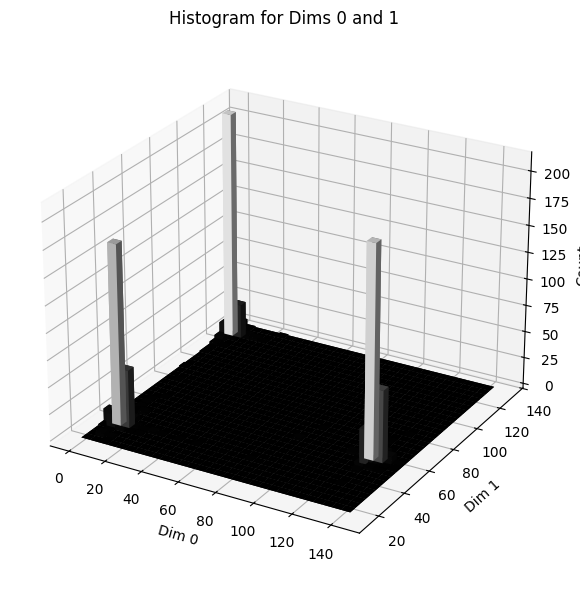

In [ ]:
#@markdown 3D Histogram of random dimensions

# """Helper function for visualization of the generated queries"""

import matplotlib.pyplot as plt


def plot_3d_histogram(data, dim_x=0, dim_y=1,
    bins=30, cmap="grey",
    elev=25, azim=-60
):
    x, y = data[:, dim_x], data[:, dim_y]
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins)

    # Use bin lower bounds directly as bar anchors
    xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
    xpos, ypos, dz = xpos.ravel(), ypos.ravel(), hist.ravel()

    dx = xedges[1] - xedges[0]
    dy = yedges[1] - yedges[0]

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))

    # Color mapping normalized to bar height
    colors = plt.colormaps[cmap](dz / dz.max()) if dz.max() > 0 else "gray"

    ax.bar3d(xpos, ypos, 0, dx, dy, dz, color=colors, shade=True)
    ax.set(
        xlabel=f"Dim {dim_x}",
        ylabel=f"Dim {dim_y}",
        zlabel="Count",
        title=f"Histogram for Dims {dim_x} and {dim_y}",
    )
    ax.view_init(elev=elev, azim=azim)

    return ax

plot_3d_histogram(query_set, dim_x=0, dim_y=1)
plt.tight_layout()
plt.show()

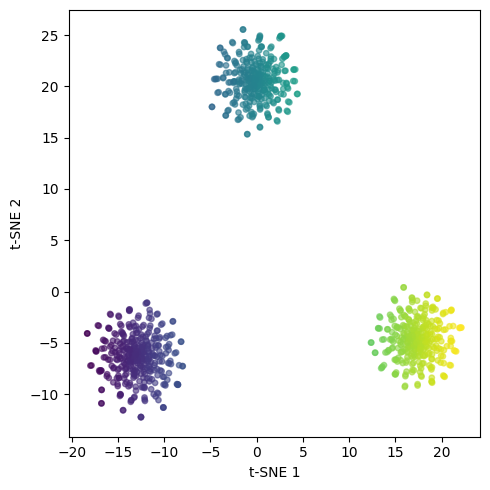

In [ ]:
#@markdown T-SNE reduction
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30.0,
    random_state=67,
)

coords_2d = tsne.fit_transform(query_set)

plt.figure(figsize=(5,5))
plt.scatter(
    coords_2d[:, 0],
    coords_2d[:, 1],
    c=coords_2d[:, 0],
    cmap="viridis",
    s=15,
    alpha=0.6
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# Graph Indexing

Cache: mettere una lista di tuple (vettore e ids), dove i vettori rappresentativi dei cluster possono essere scelti con un k-means (il k-means è effettivamente la migliore scelta se generiamo i cluster in modo isotropo e di uguale densità, altrimenti uno può usare un clustering density-based).

Provare a caircare in cache: il 1-NN, oppure gli ultimi 5 nodi prima di arrivare all'1-NN (o metà dei nodi del percorso)

Provare l'offline competitor (statico!!): assumi che la distribuzione di query sia fissa, tenere contatore per ogni nodo, e tenere in cache solo i nodi più visitati (ignora il topic drift)

### Idee su come strutturare cache

Denotiamo con $n$ la cache size, ovvero il numero di tuple (vector, id/puntatore).
Supponiamo di riservare il $50\%$ $-$ il parametro è aribtrario, necessiterebbe di fine tuning, ma non ci interessa in questo momento $-$ della cache size alla componente statica, ovvero quella che tiene i medoidi del vector DB (da capire qual è la tecnica di clustering migliore). La parte restante della cache è per la componente dinamica, ovvero basata in qualche modo sulle queries mano a mano che vengono fatte. Come viene aggiornata? La eviction policy è la semplice LRU. Cosa salviamo nella cache dinamica? Ci sono due possibilità: 1) teniamo solo il 1-NN trovato con vector search posta la query, 2) teniamo gli ultimi (gli ultimi 3, 4, 6, 7?, oppure scegliamo di alternare un nodo salvato e uno no?) che fanno parte del path per trovare il 1-NN.

Idea di codice per cache
fare classe di cache, inizializza vuota con parametro di static_size, poi chiama metodo per trovare i k-medoid e metterli in cache, infine metodi per eviction policy e aggiunta di un nuovo vettore in cache dinamica

# Cache Creation

The class creates a cache half dynamic and half static. The static part is implemented via `_compute_k_medoids`. The dynamic part starts with the function used to save the 1-NN obtained via HNSW (`update_dynamic`). Finally, `get_best_entry_point` extracts the nearest element of the query in the cache.

In [ ]:
from collections import OrderedDict
import numpy as np


class HNSWCache:
    """Gestore della cache ibrida per l'entry point routing in grafi HNSW.

    - Componente Statica (n/2): Medoidi fissi calcolati sul dataset via
    k-medoids.
    - Componente Dinamica (n/2): Buffer LRU contenente i nodi 1-NN delle query
    recenti.
    """

    def __init__(
        self, data: np.ndarray, cache_size: int = 64, random_state: int = 42
    ):
        """Inizializza la cache partizionando lo spazio e allocando le strutture.

        :param data: Matrice (N, d) contenente i vettori del database.
        :param cache_size: Dimensione complessiva della cache (n).
        :param random_state: Seed per la riproducibilità del clustering.
        """
        self.data = data
        self.cache_size = cache_size
        self.static_size = cache_size // 2
        self.dynamic_size = cache_size - self.static_size

        # Inizializzazione componente statica
        self.static_ids, self.static_vectors = self._compute_k_medoids(
            data=self.data, k=self.static_size, random_state=random_state
        )
        self.static_ids_set = set(self.static_ids)

        # Inizializzazione componente dinamica (OrderedDict come LRU: k=id, v=vettore)
        self.dynamic_cache: OrderedDict[int, np.ndarray] = OrderedDict()

    def _compute_k_medoids(
        self,
        data: np.ndarray,
        k: int,
        max_iter: int = 10,
        random_state: int = 42,
        hnsw_top_nodes: np.ndarray | list[int] | None = None, # Salvataggio nodi superiori per calcolo medoidi
    ):
        """Calcola k medoidi sul dataset tramite k-means++ seeding e refinamento PAM su cluster."""
        rng = np.random.default_rng(random_state)
        n_samples, _ = data.shape

        # Step 1: Inizializzazione rapida k-means++ per selezionare candidati distanti
        medoid_indices = [] # indici dei medoidi salvati in lista
        dist_calculated = False

        # Nodi top layer scelti come "medoidi" di partenza (cache statica)
        # Più efficienti per navigazione HNSW (in teoria)
        if hnsw_top_nodes is not None and len(hnsw_top_nodes) > 0:
           top_nodes = np.array(list(hnsw_top_nodes), dtype=np.int64)
           if len(hnsw_top_nodes) > k:
                first_idx = rng.choice(top_nodes)
                medoid_indices.append(int(first_idx))
                closest_dist_sq = np.sum((data-data[first_idx])**2, axis=1, dtype=np.float64)

                for _ in range(1,k):
                  candidate_dists = closest_dist_sq[top_nodes]
                  dist_sum = candidate_dists.sum()

                  if dist_sum > 0:
                    probs = candidate_dists / dist_sum
                    next_idx = rng.choice(top_nodes, p=probs)
                  else:
                    available = list(set(top_nodes) - set(medoid_indices))
                    next_idx = rng.choice(available)

                  medoid_indices.append(next_idx)
                  new_dist_sq = np.sum((data - data[next_idx]) ** 2, axis=1, dtype=np.float64)
                  closest_dist_sq = np.minimum(closest_dist_sq, new_dist_sq)
                dists_calculated = True
           else:
                medoid_indices = top_nodes.tolist()

        # Fallback per nessun nodo prioritario passato
        if len(medoid_indices) == 0:
            medoid_indices = [int(rng.integers(0, n_samples))]
            closest_dist_sq = np.sum((data - data[medoid_indices[0]]) ** 2, axis=1, dtype=np.float64)
            dists_calculated = True

        # Calcolo distanze inziali per kmeans sui nodi inseriti (se non già calcolate, ovvero k >= len(top_nodes))
        if not dists_calculated:
            closest_dist_sq = np.sum((data - data[medoid_indices[0]]) ** 2, axis=1, dtype=np.float64)
            for idx in medoid_indices[1:]:
                new_dist_sq = np.sum((data - data[idx]) ** 2, axis=1, dtype=np.float64)
                closest_dist_sq = np.minimum(closest_dist_sq, new_dist_sq)

        # Completamento del seeding se nodi top erano minori di k
        for _ in range(len(medoid_indices), k):
            # Azzera la probabilità di estrarre nuovamente i nodi già in cache
            closest_dist_sq[medoid_indices] = 0.0
            dist_sum = closest_dist_sq.sum()

            if dist_sum > 0:
                probs = closest_dist_sq / dist_sum
                next_idx = rng.choice(n_samples, p=probs)
            else:
                # Caso limite in cui tutti i vettori residui sono sovrapposti
                available = list(set(range(n_samples)) - set(medoid_indices))
                next_idx = rng.choice(available)

            medoid_indices.append(next_idx)
            new_dist_sq = np.sum((data - data[next_idx]) ** 2, axis=1, dtype=np.float64)
            closest_dist_sq = np.minimum(closest_dist_sq, new_dist_sq)

        medoid_indices = np.array(medoid_indices, dtype=np.int64)

        # Step 2: Refinamento iterativo (Voronoi iteration / Medoid update)
        for _ in range(max_iter):
            # Calcolo distanze dai vettori ai k medoidi: shape (n_samples, k)
            medoid_vecs = data[medoid_indices]
            # Sfrutta l'identità euclidea vettorizzata: ||x - y||^2 = ||x||^2 + ||y||^2 - 2(x . y)
            dists = (
                np.sum(data**2, axis=1, keepdims=True)
                + np.sum(medoid_vecs**2, axis=1)
                - 2 * np.dot(data, medoid_vecs.T)
            )
            labels = np.argmin(dists, axis=1)

            updated = False
            for cluster_idx in range(k):
                members = np.where(labels == cluster_idx)[0]
                if len(members) == 0:
                    continue

                # Calcola il punto interno al cluster che minimizza la somma delle distanze L2
                cluster_data = data[members]
                intra_dists = np.sum(
                    (cluster_data[:, None, :] - cluster_data[None, :, :]) ** 2,
                    axis=-1,
                )
                best_member_idx = members[np.argmin(intra_dists.sum(axis=1))]

                # Controllo per forzare presenza dei top nodi dell'HNSW nella static cache
                if hnsw_top_nodes is not None and medoid_indices[cluster_idx] in hnsw_top_nodes:
                    continue

                if best_member_idx != medoid_indices[cluster_idx]:
                    medoid_indices[cluster_idx] = best_member_idx
                    updated = True

            if not updated:
                break

        return medoid_indices, data[medoid_indices]

    def get_best_entry_point(self, query: np.ndarray) -> tuple[int, float]:
        """Scansiona l'intera cache (statica + dinamica) e individua il nodo più vicino alla query.

        :param query: Vettore 1D della query.
        :return: Tupla (best_node_id, min_distance_sq).
        """
        # Estrazione nodi e coordinate dalla parte dinamica
        dynamic_ids = list(self.dynamic_cache.keys())
        dynamic_vectors = (
            np.array(list(self.dynamic_cache.values()))
            if dynamic_ids
            else np.empty((0, query.shape[0]), dtype=self.data.dtype)
        )

        # Unione dei vettori candidati per una singola operazione vettorizzata L2
        if len(dynamic_ids) > 0:
            all_ids = np.concatenate([self.static_ids, dynamic_ids])
            all_vectors = np.vstack([self.static_vectors, dynamic_vectors])
        else:
            all_ids = self.static_ids
            all_vectors = self.static_vectors

        # Calcolo distanze L2 al quadrato
        diff = all_vectors - query
        dists_sq = np.sum(diff * diff, axis=1)

        best_pos = int(np.argmin(dists_sq))
        return int(all_ids[best_pos]), float(dists_sq[best_pos])

    def update_dynamic(self, node_id: int, vector: np.ndarray | None = None):
        """Aggiorna la componente LRU con il 1-NN individuato al termine della ricerca HNSW.

        :param node_id: ID del nodo restituito dalla ricerca.
        :param vector: Vettore associato all'ID (se None, recuperato da data).
        """
        # Se il nodo appartiene già alla componente statica, non duplica lo spazio
        if node_id in self.static_ids_set:
            return None

        if vector is None:
            vector = self.data[node_id]

        # Politica LRU: se presente rinfresca la priorità, altrimenti inserisce
        if node_id in self.dynamic_cache:
            self.dynamic_cache.move_to_end(node_id)
        else:
            if len(self.dynamic_cache) >= self.dynamic_size:
                # Eviction del nodo meno recentemente utilizzato (FIFO/LRU head)
                self.dynamic_cache.popitem(last=False)
            self.dynamic_cache[node_id] = vector


# Inizializzazione della cache sul dataset
# cache_manager = HNSWCache(data=data, cache_size=64, random_state=67676767676767)

# HNSW implementation

This class implements HNSW in order to save the number of hops made to get the 1-NN.

In [ ]:
import heapq
import numpy as np


class InstrumentedHNSW:
    """Implementazione HNSW per tracciare il numero di hops

    e supportare entry point arbitrari (provenienti da cache).
    """

    def __init__(
        self,
        data: np.ndarray,
        M: int = 16,
        ef_construction: int = 40,
        random_state: int = 42,
    ):
        self.data = data
        self.N, self.dim = data.shape
        self.M = M
        self.M0 = 2 * M
        self.ef_construction = ef_construction
        self.mL = 1.0 / np.log(M)
        self.rng = np.random.default_rng(random_state)

        # Struttura del grafo: lista di dizionari per ogni layer {node_id: list_of_neighbors}
        self.layers: list[dict[int, list[int]]] = [{}]
        self.node_levels = np.zeros(self.N, dtype=np.int32)
        self.enter_point: int | None = None
        self.max_level: int = -1

        self._build_index()

    def _dist_sq(self, q: np.ndarray, node_ids: list[int] | int) -> np.ndarray:
        """Distanza euclidea al quadrato vettorizzata."""
        if isinstance(node_ids, (int, np.integer)):
            diff = self.data[node_ids] - q
            return float(np.dot(diff, diff))
        diff = self.data[node_ids] - q
        return np.sum(diff * diff, axis=1)

    def _assign_level(self) -> int:
        """Assegna un livello secondo la distribuzione esponenziale di HNSW."""
        r = self.rng.uniform(1e-9, 1.0)
        return int(-np.log(r) * self.mL)

    def _build_index(self):
        """Costruisce il grafo HNSW inserendo progressivamente tutti i vettori."""
        for i in range(self.N):
            level = self._assign_level()
            self.node_levels[i] = level

            while len(self.layers) <= level:
                self.layers.append({})

            if self.enter_point is None:
                for lc in range(level + 1):
                    self.layers[lc][i] = []
                self.enter_point = i
                self.max_level = level
                continue

            curr_ep = self.enter_point
            q_vec = self.data[i]

            # 1. Greedy descent fino al livello di inserimento
            for lc in range(self.max_level, level, -1):
                changed = True
                while changed:
                    changed = False
                    neighbors = self.layers[lc].get(curr_ep, [])
                    if not neighbors:
                        break
                    dists = self._dist_sq(q_vec, neighbors)
                    min_idx = np.argmin(dists)
                    if dists[min_idx] < self._dist_sq(q_vec, curr_ep):
                        curr_ep = neighbors[min_idx]
                        changed = True

            # 2. Connessione nei layer da min(level, max_level) a 0
            for lc in range(min(level, self.max_level), -1, -1):
                # Beam search locale per trovare i candidati
                candidates = self._search_layer(
                    q_vec, curr_ep, ef=self.ef_construction, lc=lc
                )
                m_max = self.M0 if lc == 0 else self.M

                # Selezione dei vicini più prossimi
                cand_ids = [idx for _, idx in candidates]
                cand_dists = self._dist_sq(q_vec, cand_ids)
                best_neighbors = [
                    cand_ids[idx]
                    for idx in np.argsort(cand_dists)[:m_max]
                    if cand_ids[idx] != i
                ]

                self.layers[lc][i] = best_neighbors

                # Connessioni bidirezionali e potatura gradi
                for neighbor in best_neighbors:
                    self.layers[lc].setdefault(neighbor, []).append(i)
                    if len(self.layers[lc][neighbor]) > m_max:
                        n_neighbors = self.layers[lc][neighbor]
                        d = self._dist_sq(self.data[neighbor], n_neighbors)
                        self.layers[lc][neighbor] = [
                            n_neighbors[idx]
                            for idx in np.argsort(d)[:m_max]
                        ]

                curr_ep = candidates[0][1]

            if level > self.max_level:
                self.max_level = level
                self.enter_point = i

    def _search_layer(
        self, q: np.ndarray, ep: int, ef: int, lc: int
    ) -> list[tuple[float, int]]:
        """Esplorazione con priority queue (beam search) per un singolo livello."""
        v_dist = self._dist_sq(q, ep)
        visited = {ep}
        candidates = [(v_dist, ep)]  # min-heap
        w = [(-v_dist, ep)]  # max-heap per tracciare i migliori 'ef'

        while candidates:
            c_dist, c_id = heapq.heappop(candidates)
            furthest_w_dist = -w[0][0]

            if c_dist > furthest_w_dist:
                break

            neighbors = self.layers[lc].get(c_id, [])
            for n in neighbors:
                if n not in visited:
                    visited.add(n)
                    n_dist = self._dist_sq(q, n)
                    if n_dist < furthest_w_dist or len(w) < ef:
                        heapq.heappush(candidates, (n_dist, n))
                        heapq.heappush(w, (-n_dist, n))
                        if len(w) > ef:
                            heapq.heappop(w)

        return sorted([(-d, idx) for d, idx in w])

    def search(
        self,
        query: np.ndarray,
        ef: int = 32,
        custom_entry_id: int | None = None,
        enter_at_layer_zero: bool = False,
    ) -> dict:
        """Esegue la ricerca del 1-NN tracciando gli hop totali percorsi.

        :param custom_entry_id: Nodo di partenza (se None, usa l'entry point globale).
        :param enter_at_layer_zero: Se True, inizia direttamente al Layer 0 saltando i livelli alti.
        """
        hops = 0

        # Possibile forma di riduzione degli hops per cache modeled, tuttavia non abbiamo idea di valore ottimale per non rovinare performance
        # # Enter at zero = True significa che, se usiamo la cache, riduciamo l'EF per velocizzare ricerca locale
        # if enter_at_layer_zero:
        #     ef = min(ef, 8)

        # Determinazione punto e livello di ingresso
        if custom_entry_id is None:
            curr_obj = self.enter_point
            curr_level = self.max_level
        else:
            curr_obj = custom_entry_id
            curr_level = 0 if enter_at_layer_zero else min(self.node_levels[custom_entry_id], self.max_level)

        curr_dist = self._dist_sq(query, curr_obj)

        # 1. Routing greedy sui layer superiori (> 0)
        for lc in range(curr_level, 0, -1):
            changed = True
            while changed:
                changed = False
                neighbors = self.layers[lc].get(curr_obj, [])
                if not neighbors:
                    break
                dists = self._dist_sq(query, neighbors)
                min_idx = np.argmin(dists)
                if dists[min_idx] < curr_dist:
                    curr_dist = dists[min_idx]
                    curr_obj = neighbors[min_idx]
                    hops += 1
                    changed = True

        # 2. Beam search al Layer 0
        visited = {curr_obj}
        candidates = [(curr_dist, curr_obj)]
        w = [(-curr_dist, curr_obj)]

        while candidates:
            c_dist, c_id = heapq.heappop(candidates)
            furthest_w = -w[0][0]

            if c_dist > furthest_w:
                break

            neighbors = self.layers[0].get(c_id, [])
            for n in neighbors:
                if n not in visited:
                    visited.add(n)
                    hops += 1  # Hop topologico: visita ed espansione nodo adiacente
                    n_dist = self._dist_sq(query, n)

                    if n_dist < furthest_w or len(w) < ef:
                        heapq.heappush(candidates, (n_dist, n))
                        heapq.heappush(w, (-n_dist, n))
                        if len(w) > ef:
                            heapq.heappop(w)

        best_dist, best_node = min((-neg_d, idx) for neg_d, idx in w)
        return {"node": best_node, "distance_sq": best_dist, "hops": hops}

# Number of hops Comparison

In [ ]:
# # 1. Indicizzazione HNSW (su subset o intero dataset)
hnsw_index = InstrumentedHNSW(data=data, M=16, ef_construction=32, random_state=42)

# # 2. Inizializzazione e warm-up della cache con le query sintetiche
# cache = HNSWCache(data=data, cache_size=64, random_state=42)

# # Warm-up: popola la componente LRU con i primi 100 risultati di query power-law
# warmup_queries = query_set[:100]
# for q in warmup_queries:
#     res = hnsw_index.search(q, ef=32)
#     cache.update_dynamic(node_id=res["node"])

# # 3. Test comparativo su una query target
# test_query = query_set[101]

# # Ricerca Standard (Entry Point predefinito al top-layer)
# res_standard = hnsw_index.search(test_query, ef=32)

# # Ricerca Cache-Assisted (Selezione best entry point da cache -> Layer 0)
# best_cached_id, _ = cache.get_best_entry_point(test_query)
# res_cache = hnsw_index.search(
#     test_query, ef=32, custom_entry_id=best_cached_id, enter_at_layer_zero=True
# )

# # 4. Report metriche
# print(
#     f"{'Metrica':<25} | {'HNSW Standard':<15} | {'HNSW + Cache':<15}\n"
#     f"{'-'*60}\n"
#     f"{'Entry Point ID':<25} | {str(hnsw_index.enter_point):<15} | {str(best_cached_id):<15}\n"
#     f"{'1-NN Restituito':<25} | {str(res_standard['node']):<15} | {str(res_cache['node']):<15}\n"
#     f"{'Distanza L2 al quadrato':<25} | {res_standard['distance_sq']:<15.2f} | {res_cache['distance_sq']:<15.2f}\n"
#     f"{'Totale Hops':<25} | {str(res_standard['hops']):<15} | {str(res_cache['hops']):<15}\n"
#     f"{'Hops Risparmiati':<25} | {'0%':<15} | {(1 - res_cache['hops']/res_standard['hops']) * 100:<14.1f}%\n"
#     f"{'-'*60}"
# )

# Experiment
This section evaluates the routing efficiency of the hybrid-cached HNSW index compared to the standard top-layer entry point approach, focusing on graph traversal hops across varying cache capacities and query workload states.

1. **Evaluation Routine**: `benchmark_cache_dynamics`

The` benchmark_cache_dynamics` function measures convergence speed and routing quality by isolating the dynamic cache warmup from evaluation:
Workload Partitioning: Splits the synthetic query workload into a dedicated

*   Workload Partitioning: Splits the synthetic query workload into a dedicated validation slice (`test_queries`) and a sequential traffic stream (`stream_queries`).
*   Uncached Baseline: Executes standard HNSW greedy traversal (starting from the global top-layer entry point) across the validation set to establish baseline hop counts and true 1-NN retrieval targets.
*   Parametric Grid Search: Evaluates multiple total cache capacities ($N \in \{64, 128, 256\}$) across progressive historical stream checkpoints ($0, 25, 50, \dots, 400$ processed queries).
* The metrics extracted are 4. *Mean Traversal Hops*: Average edge transitions required to reach the terminal 1-NN candidate. *Hop Reduction* (%): Relative percentage of traversal steps saved compared to baseline HNSW. *Recall vs. Standard* (%): Consistency rate of the returned 1-NN relative to standard HNSW, ensuring direct Layer-0 entry points do not induce local minima traps. *LRU Utilization* (%): Dynamic buffer saturation level.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def benchmark_cache_dynamics(
    hnsw_index: InstrumentedHNSW,
    data: np.ndarray,
    queries: np.ndarray,
    cache_sizes: list[int] = [64, 128, 256],
    checkpoints: list[int] = [0, 25, 50, 100, 200, 400],
    n_test_queries: int = 100,
    ef_search: int = 32
):
    """
    Misura gli hop medi al variare della capacità della cache e dello stato
    di popolamento della componente dinamica.
    """
    # 1. Separazione tra stream di warmup/traffico e pool di validazione
    test_queries = queries[:n_test_queries]
    stream_queries = queries[n_test_queries:]

    max_checkpoint = max(checkpoints)
    if len(stream_queries) < max_checkpoint:
        raise ValueError(f"Servono almeno {max_checkpoint + n_test_queries} query totali.")

    # 2. Baseline HNSW standard (indipendente dalla cache)
    std_hops = []
    std_results = []
    for q in test_queries:
        res = hnsw_index.search(q, ef=ef_search)
        std_hops.append(res["hops"])
        std_results.append(res["node"])

    baseline_avg_hops = float(np.mean(std_hops))
    print(f"[*] Baseline HNSW (Senza Cache): {baseline_avg_hops:.2f} hop medi\n")

    records = []

    # 3. Griglia di test: Cache Size x Checkpoints di query eseguite
    for c_size in cache_sizes:
        print(f"--- Valutazione Cache Size = {c_size} ---")
        cache = HNSWCache(data=data, cache_size=c_size, random_state=42)
        stream_ptr = 0

        for cp in checkpoints:
            # Avanza lo stream fino al checkpoint corrente aggiornando la LRU
            while stream_ptr < cp:
                q_stream = stream_queries[stream_ptr]
                best_ep, _ = cache.get_best_entry_point(q_stream)
                res_stream = hnsw_index.search(
                    q_stream,
                    ef=ef_search,
                    custom_entry_id=best_ep,
                    enter_at_layer_zero=True
                )
                cache.update_dynamic(node_id=res_stream["node"])
                stream_ptr += 1

            # Valutazione sul test set al checkpoint attuale
            test_hops = []
            matching_hits = 0

            for idx, q in enumerate(test_queries):
                best_ep, _ = cache.get_best_entry_point(q)
                res = hnsw_index.search(
                    q,
                    ef=ef_search,
                    custom_entry_id=best_ep,
                    enter_at_layer_zero=True
                )
                test_hops.append(res["hops"])

                # Controllo coerenza del 1-NN rispetto alla baseline standard
                if res["node"] == std_results[idx]:
                    matching_hits += 1

            avg_hops = float(np.mean(test_hops))
            hop_delta_pct = (1.0 - (avg_hops / baseline_avg_hops)) * 100.0
            recall_vs_std = (matching_hits / n_test_queries) * 100.0

            records.append({
                "Cache Size": c_size,
                "Query Eseguite": cp,
                "Hop Medi": round(avg_hops, 2),
                "Hop Risparmiati (%)": round(hop_delta_pct, 1),
                "Recall vs Std (%)": round(recall_vs_std, 1),
                "Effective dynamic cache size (%)": round((len(cache.dynamic_cache) / cache.dynamic_size) * 100.0, 1) # in realtà misura quanto è piena la cache rispetto alla lunghezza massima preallocata
            })

    results_df = pd.DataFrame(records)
    return results_df, baseline_avg_hops

2. **Pipeline Execution & Convergence Plotting**

The execution block runs the parameter sweep and visualizes the interaction between static coverage and dynamic adaptation:


*   Tabular Aggregation: Summarizes retrieval metrics in a pandas.DataFrame across all combinations of cache capacity and warm-up milestones.
*   Trajectory Visualization: Plots mean hop trajectories against the number of historical stream queries, with a dashed reference line for the baseline HNSW cost.
* Dynamics Captured: **Checkpoint 0 (Cold Start)**: Reflects hop reduction achieved purely through static Voronoi coverage via the $k$-medoids subset ($k = N / 2$). **Transient Phase**: Captures the steep drop in hops as power-law query clusters populate the dynamic LRU cache, enabling near-immediate convergence to target local graph neighborhoods. **Steady State**: Identifies the saturation plateau and highlights potential LRU thrashing when cluster variety exceeds dynamic capacity.

In [ ]:
print(len(query_set))
print(len(hnsw_index.layers[2]))

1000
39


In [ ]:
first_query = query_set[0:1]
query_set_debug = np.repeat(first_query, len(query_set), axis=0)


print(query_set.shape)
print(query_set_debug.shape) # Same shape as query generator

(1000, 128)
(1000, 128)


In [ ]:
np.all(query_set_debug == query_set_debug[0])

np.True_

[*] Baseline HNSW (Senza Cache): 640.25 hop medi

--- Valutazione Cache Size = 64 ---
--- Valutazione Cache Size = 128 ---
--- Valutazione Cache Size = 256 ---


,Cache Size,Query Eseguite,Hop Medi,Hop Risparmiati (%),Recall vs Std (%),Effective dynamic cache size (%)
0,64,1,575.54,10.1,0.0,3.1
1,64,25,565.69,11.6,0.0,6.2
2,64,50,565.69,11.6,0.0,6.2
3,64,100,565.69,11.6,0.0,6.2
4,64,200,565.69,11.6,0.0,12.5
5,64,400,567.86,11.3,0.0,18.8
6,128,1,582.80,9.0,32.0,1.6
7,128,25,565.69,11.6,0.0,4.7
8,128,50,565.69,11.6,0.0,4.7
9,128,100,565.69,11.6,0.0,4.7


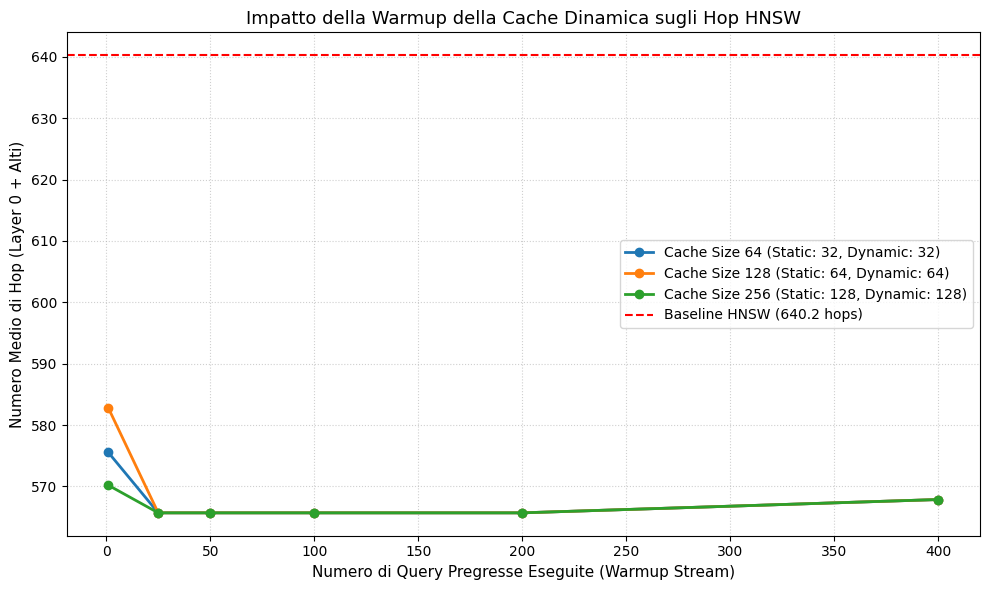

In [ ]:
# Esecuzione del benchmark
checkpoints_list = [1, 25, 50, 100, 200, 400]
cache_sizes_list = [64, 128, 256]

df_results, baseline_hops = benchmark_cache_dynamics(
    hnsw_index=hnsw_index,
    data=data,
    queries=query_set,
    cache_sizes=cache_sizes_list,
    checkpoints=checkpoints_list,
    n_test_queries=100,
    ef_search=32
)

# Visualizzazione tabellare
display(df_results)

# Plot delle curve di convergenza
plt.figure(figsize=(10, 6))

for c_size in cache_sizes_list:
    subset = df_results[df_results["Cache Size"] == c_size]
    plt.plot(
        subset["Query Eseguite"],
        subset["Hop Medi"],
        marker='o',
        linewidth=2,
        label=f"Cache Size {c_size} (Static: {c_size//2}, Dynamic: {c_size//2})"
    )

plt.axhline(
    y=baseline_hops,
    color='r',
    linestyle='--',
    linewidth=1.5,
    label=f"Baseline HNSW ({baseline_hops:.1f} hops)"
)

plt.title("Impatto della Warmup della Cache Dinamica sugli Hop HNSW", fontsize=13)
plt.xlabel("Numero di Query Pregresse Eseguite (Warmup Stream)", fontsize=11)
plt.ylabel("Numero Medio di Hop (Layer 0 + Alti)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### TODO Fare tests al variare del parametro dynamic-to-static
### (TODO Vedere quanto spesso vengono usati i vettori in cache dinamica)
### Fare confronto tra veri 1-NN e i risultati nostri e di HNSW

### TODO Vedere come il numero di cluster della query distribution interagisce con la lunghezza ottimale della cache dinamica


- Fare test di debugging chiedendo sempre la stessa query

- Contare il numero di hop per livello (data la query). Auspicabilmente, ci sono pochi hop nell'ultimo livello.
- Tenere in cache statica i vettori del livello più alto
- Pensare a una forma di biased skip list in salsa HNSW

(aggiungere i medoidi con probabilità pari alla densità delle query che hanno quel medoide come più vicino)